# Analyse generale et EDA de `data3`

Objectif: comprendre le contenu des fichiers dans `data3`, verifier la qualite des donnees, puis produire une exploration descriptive par theme: evenements, associations, tournages, equipements sport/culture, commerces, terrasses et zones touristiques.

In [1]:
from pathlib import Path
import struct
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

DATA_DIR = Path('data3')
assert DATA_DIR.exists(), 'Le dossier data3 est introuvable'


## Fonctions utilitaires

In [2]:
def fix_mojibake(value):
    """Corrige certains textes lus en latin1 alors qu'ils sont en cp1252/utf-8."""
    if pd.isna(value) or not isinstance(value, str):
        return value
    for src, dst in [('latin1', 'utf-8'), ('latin1', 'cp1252')]:
        try:
            decoded = value.encode(src).decode(dst)
            if 'Ã' not in decoded and '�' not in decoded:
                return decoded
        except Exception:
            pass
    return value


def read_dbf(path, limit=None, encoding='latin1'):
    """Lecture simple des attributs DBF sans dependance geopandas/fiona."""
    path = Path(path)
    with path.open('rb') as f:
        header = f.read(32)
        n_records = struct.unpack('<I', header[4:8])[0]
        header_len = struct.unpack('<H', header[8:10])[0]
        record_len = struct.unpack('<H', header[10:12])[0]

        raw_fields = []
        while True:
            desc = f.read(32)
            if not desc or desc[0] == 0x0D:
                break
            name = desc[:11].split(b'\x00', 1)[0].decode(encoding, errors='replace')
            ftype = chr(desc[11])
            length = desc[16]
            decimals = desc[17]
            raw_fields.append((name, ftype, length, decimals))

        counts = {}
        fields = []
        for name, *rest in raw_fields:
            counts[name] = counts.get(name, 0) + 1
            safe_name = name if counts[name] == 1 else f'{name}_{counts[name]}'
            fields.append((safe_name, *rest))

        f.seek(header_len)
        rows = []
        max_records = n_records if limit is None else min(limit, n_records)
        for _ in range(max_records):
            rec = f.read(record_len)
            if not rec or rec[:1] == b'*':
                continue
            pos = 1
            row = {}
            for name, ftype, length, decimals in fields:
                raw = rec[pos:pos + length]
                pos += length
                value = raw.decode(encoding, errors='replace').strip()
                if ftype in ('N', 'F'):
                    value = pd.to_numeric(value, errors='coerce')
                else:
                    value = fix_mojibake(value)
                row[name] = value
            rows.append(row)
    return pd.DataFrame(rows)


def overview(df, name):
    return pd.DataFrame({
        'dataset': name,
        'rows': len(df),
        'columns': df.shape[1],
        'missing_cells_%': round(df.isna().mean().mean() * 100, 2),
        'duplicated_rows': int(df.duplicated().sum())
    }, index=[0])


def missing_report(df):
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_%': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(dropna=True)
    })
    return out.sort_values(['missing_%', 'unique'], ascending=[False, False])


## 1. Inventaire des fichiers

In [3]:
inventory = []
for path in sorted(DATA_DIR.rglob('*')):
    if path.is_file():
        inventory.append({
            'path': str(path),
            'extension': path.suffix.lower(),
            'size_mb': round(path.stat().st_size / 1024 / 1024, 2)
        })

inventory_df = pd.DataFrame(inventory).sort_values('size_mb', ascending=False)
inventory_df


,path,extension,size_mb
0,data3\DS_BPE_SPORT_CULTURE_2024_CSV_FR\DS_BPE_SPORT_CULTURE_2024_data.csv,.csv,128.47
10,data3\terrasses-autorisations\terrasses-autorisations.dbf,.dbf,46.84
2,data3\les-commerces-par-commune-ou-arrondissement-base-permanente-des-equipements\les-commerces-par-commune-ou-arron...,.dbf,9.80
8,data3\que-faire-a-paris-.parquet,.parquet,4.73
1,data3\DS_BPE_SPORT_CULTURE_2024_CSV_FR\DS_BPE_SPORT_CULTURE_2024_metadata.csv,.csv,1.51
6,data3\lieux-de-tournage-a-paris.parquet,.parquet,0.99
7,data3\liste_des_associations_parisiennes.parquet,.parquet,0.83
12,data3\terrasses-autorisations\terrasses-autorisations.shp,.shp,0.64
4,data3\les-commerces-par-commune-ou-arrondissement-base-permanente-des-equipements\les-commerces-par-commune-ou-arron...,.shp,0.31
13,data3\terrasses-autorisations\terrasses-autorisations.shx,.shx,0.18


## 2. Chargement des donnees

In [4]:
tournages = pd.read_parquet(DATA_DIR / 'lieux-de-tournage-a-paris.parquet')
associations = pd.read_parquet(DATA_DIR / 'liste_des_associations_parisiennes.parquet')
qfap = pd.read_parquet(DATA_DIR / 'que-faire-a-paris-.parquet')
zones = pd.read_parquet(DATA_DIR / 'zones-touristiques-internationales.parquet')

bpe_path = DATA_DIR / 'DS_BPE_SPORT_CULTURE_2024_CSV_FR' / 'DS_BPE_SPORT_CULTURE_2024_data.csv'
bpe_meta_path = DATA_DIR / 'DS_BPE_SPORT_CULTURE_2024_CSV_FR' / 'DS_BPE_SPORT_CULTURE_2024_metadata.csv'
bpe = pd.read_csv(bpe_path, sep=';', low_memory=False)
bpe_meta = pd.read_csv(bpe_meta_path, sep=';')

commerces = read_dbf(DATA_DIR / 'les-commerces-par-commune-ou-arrondissement-base-permanente-des-equipements' / 'les-commerces-par-commune-ou-arrondissement-base-permanente-des-equipements.dbf')
terrasses = read_dbf(DATA_DIR / 'terrasses-autorisations' / 'terrasses-autorisations.dbf')

datasets = {
    'tournages': tournages,
    'associations': associations,
    'qfap': qfap,
    'zones': zones,
    'bpe': bpe,
    'bpe_meta': bpe_meta,
    'commerces': commerces,
    'terrasses': terrasses,
}

pd.concat([overview(df, name) for name, df in datasets.items()], ignore_index=True)


,dataset,rows,columns,missing_cells_%,duplicated_rows
0,tournages,14760,14,0.22,0
1,associations,70993,11,3.58,0
2,qfap,3387,69,46.41,0
3,zones,12,12,0.00,0
4,bpe,1351761,19,0.00,0
5,bpe_meta,35722,4,0.00,1709
6,commerces,1300,31,0.00,0
7,terrasses,23877,10,0.01,356


## 3. Qualite globale des donnees

In [5]:
for name, df in datasets.items():
    print(f'\n=== {name} ===')
    display(missing_report(df).head(15))



=== tournages ===


,dtype,missing,missing_%,unique
nom_realisateur,object,420,2.85,1554
nom_producteur,object,32,0.22,1102
ardt_lieu,object,1,0.01,28
id_lieu,object,0,0.00,14760
coord_x,float64,0,0.00,9180
coord_y,float64,0,0.00,9163
geo_shape,object,0,0.00,8775
geo_point_2d,object,0,0.00,8775
adresse_lieu,object,0,0.00,8545
date_fin,object,0,0.00,2625



=== associations ===


,dtype,missing,missing_%,unique
sa_secteur_d_activit_3,object,14893,20.98,20
sa_secteur_d_activit_2,object,5079,7.15,21
cl_id_partenaire,float64,1001,1.41,2782
cp_adresse_code_postal,float64,1001,1.41,165
cp_adresse_ville,object,1001,1.41,149
sg_secteur_gographique,object,1001,1.41,24
sa_secteur_d_activit_1,object,1001,1.41,22
sa_libell_secteur_d_activit,object,1001,1.41,22
pv_public_vis,object,1001,1.41,16
sa_libell_domaine_d_activit,object,1001,1.41,6



=== qfap ===


...

,dtype,missing,missing_%,unique
COD_MOD,object,0,0.0,32034
LIB_MOD,object,0,0.0,28755
COD_VAR,object,0,0.0,17
LIB_VAR,object,0,0.0,17



=== commerces ===


,dtype,missing,missing_%,unique
departement_2,int64,0,0.0,1300
libelle_de_,object,0,0.0,1296
population_,int64,0,0.0,1126
canton_vill,int64,0,0.0,267
unite_urbai,object,0,0.0,104
magasin_de_,int64,0,0.0,94
boulangerie,int64,0,0.0,64
epicerie,int64,0,0.0,61
librairie_p,int64,0,0.0,48
magasin_d_o,int64,0,0.0,44



=== terrasses ===


,dtype,missing,missing_%,unique
longueur,float64,13,0.05,1302
largeur,float64,13,0.05,446
adresse,object,0,0.00,14778
siret,object,0,0.00,14413
nom_enseign,object,0,0.00,13608
lien_affich,object,0,0.00,11278
nom_societe,object,0,0.00,354
typologie,object,0,0.00,33
arrondissem,object,0,0.00,22
periode_ins,object,0,0.00,9


## 4. Evenements Que Faire a Paris

,title,date_start,date_end,address_zipcode,price_type,qfap_tags
0,"Visite guidée du jardin d'agronomie tropicale, René Dumont",2026-06-15 18:00:00+02:00,2026-09-16 20:00:00+02:00,75012,gratuit,Histoire;Nature
1,TEAR CLUB célèbre l'intensité émotionnelle (sur le dancefloor) : vendredi 29 mai à La Machine !,2026-05-30 02:55:00+02:00,2026-05-30 09:00:00+02:00,75018,payant,Nuit
2,"Voyage musical en compagnie de Schubert et Debussy, Lieder et mélodies",2026-07-03 22:00:00+02:00,2026-07-03 23:30:00+02:00,75006,payant,Concert
3,"Le Club Coca-Cola s'installe Quai de la Photo, pour la Coupe du Monde 2026",2026-06-12 02:00:00+02:00,2026-07-20 01:59:59+02:00,75013,gratuit sous condition,None
4,L'Histoire au scalpel,2026-05-29 21:30:00+02:00,2026-05-29 22:30:00+02:00,75005,gratuit,Conférence;Histoire


price_type
gratuit                   1957
payant                    1269
gratuit sous condition     161
Name: events_by_price, dtype: int64

address_zipcode
75004    298
75019    256
75012    241
75018    237
75013    218
75001    205
75020    190
None     171
75014    164
75005    153
75011    141
75008    129
75010    128
75015    119
75003    117
Name: events_by_zipcode, dtype: int64

qfap_tags
Concert              915
Atelier              546
Festival             485
Loisirs              477
Enfants              435
Expo                 359
Art contemporain     319
Théâtre              310
Sport                305
Histoire             244
Danse                219
Balade urbaine       206
Conférence           206
Littérature          199
Nuit                 164
Spectacle musical    156
Solidarité           146
Nature               116
Ecrans                93
Photo                 72
Name: top_tags, dtype: int64

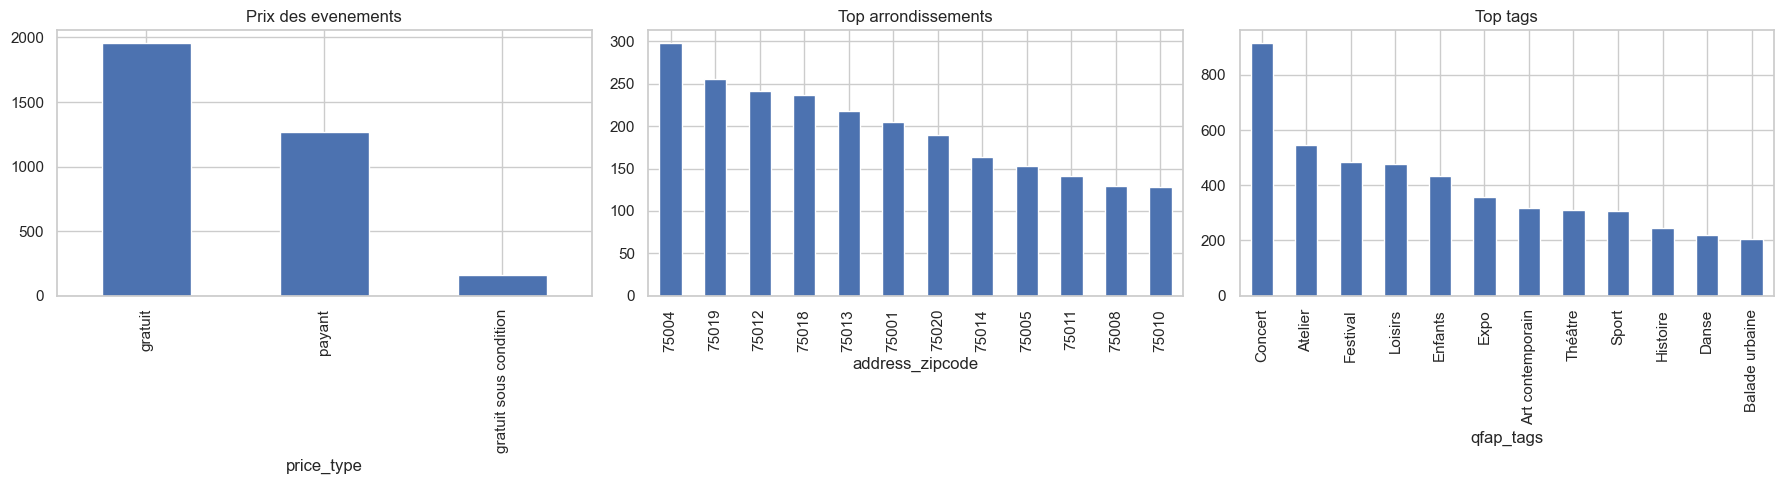

In [6]:
qfap_tags = qfap['qfap_tags'].dropna().str.split(';').explode().str.strip()

display(qfap[['title', 'date_start', 'date_end', 'address_zipcode', 'price_type', 'qfap_tags']].head())
display(qfap['price_type'].value_counts(dropna=False).rename('events_by_price'))
display(qfap['address_zipcode'].value_counts(dropna=False).head(15).rename('events_by_zipcode'))
display(qfap_tags.value_counts().head(20).rename('top_tags'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
qfap['price_type'].value_counts().plot(kind='bar', ax=axes[0], title='Prix des evenements')
qfap['address_zipcode'].value_counts().head(12).plot(kind='bar', ax=axes[1], title='Top arrondissements')
qfap_tags.value_counts().head(12).plot(kind='bar', ax=axes[2], title='Top tags')
plt.tight_layout()


## 5. Associations parisiennes

,pr_nom_statutaire,cp_adresse_code_postal,cp_adresse_ville,sa_secteur_d_activit_1,sa_secteur_d_activit_2,sa_secteur_d_activit_3,sa_libell_domaine_d_activit,sa_libell_secteur_d_activit,pv_public_vis,sg_secteur_gographique,cl_id_partenaire
0,YOGA ET CETERA,75018.0,PARIS,Sport,Culture & Arts,Sant‚,Culture & Education,Culture & Arts,Adultes,National,1350.0
1,CHOEUR · PRENDRE,75015.0,PARIS,Loisirs,Culture & Arts,None,Culture & Education,Culture & Arts,Femmes,Paris 15,29455.0
2,COMPAGNIE VARSORIO,75019.0,PARIS,Culture & Arts,Education & formation,Vie et animation locale,Vie Locale et Citoyenne,Vie et animation locale,Professionnels,International,1866.0
3,COMITE REGIONAL DE L'ACADEMIE DE PARIS DE LA FEDERATION FRANCAISE DU SPORT UNIVERSITAIRE CRSU,75014.0,PARIS,Sport,Loisirs,Education & formation,Sports Loisirs,Sport,Tous,Ile de France,435.0
4,ERSR (ECOLE DE LA RESPIRATION SANDRA-ROMOND),75020.0,PARIS,Sport,Education & formation,Sant‚,Sports Loisirs,Sport,Tous,Paris 7,9323.0


sa_libell_domaine_d_activit
Culture & Education        23343
Sports Loisirs             21306
Solidarit‚ et Sant‚        12708
Vie Locale et Citoyenne     9237
Environnement Urbanisme     2067
Economie et Emploi          1331
None                        1001
Name: domaines, dtype: int64

sa_secteur_d_activit_1
Sport                       28926
Culture & Arts              13894
Loisirs                      8539
Education & formation        7552
Social                       6050
Environnement & ‚cologie     1276
None                         1001
Technique & Recherche         962
Sant‚                         754
Tourisme                      528
Humanitaire                   321
Pr‚carit‚ & Exclusion         272
Name: secteur_1, dtype: int64

cp_adresse_code_postal
75013    9592
75019    6935
75018    6461
75011    4779
75010    4687
75015    4344
75020    4080
75014    4042
75005    3022
75012    2890
75016    2488
75003    1921
75017    1918
75007    1900
75002    1623
Name: associations_by_zipcode, dtype: int64

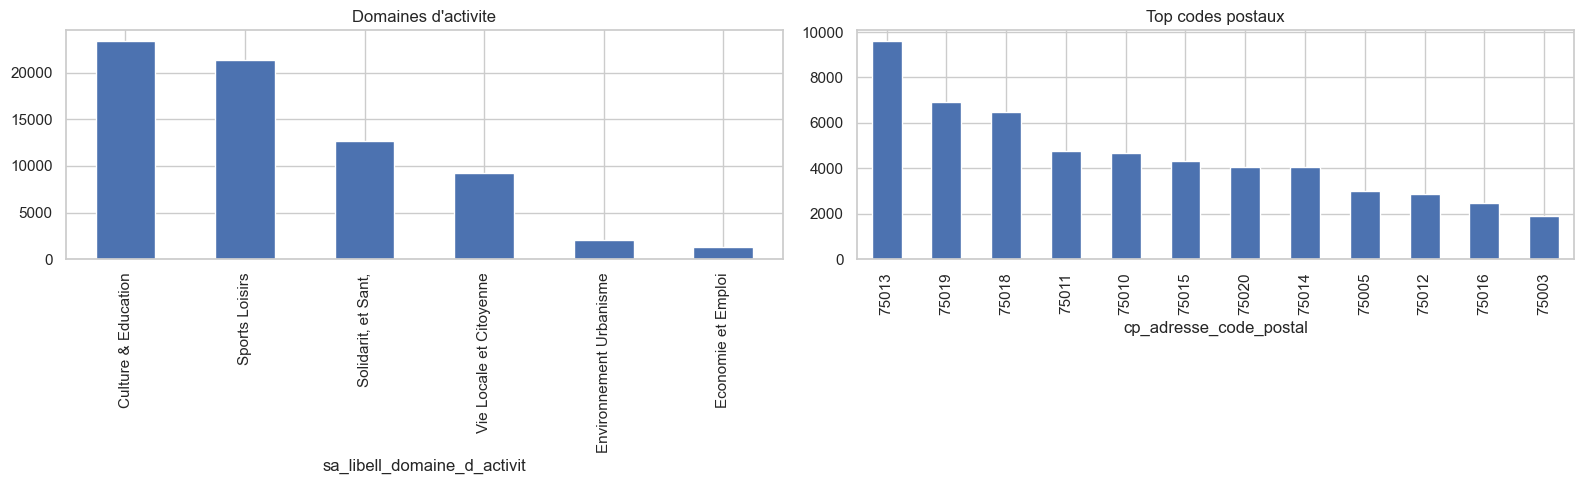

In [7]:
for col in associations.select_dtypes(include='object').columns:
    associations[col] = associations[col].map(fix_mojibake)

display(associations.head())
display(associations['sa_libell_domaine_d_activit'].value_counts(dropna=False).head(12).rename('domaines'))
display(associations['sa_secteur_d_activit_1'].value_counts(dropna=False).head(12).rename('secteur_1'))
display(associations['cp_adresse_code_postal'].dropna().astype(int).astype(str).value_counts().head(15).rename('associations_by_zipcode'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
associations['sa_libell_domaine_d_activit'].value_counts().head(10).plot(kind='bar', ax=axes[0], title='Domaines d\'activite')
associations['cp_adresse_code_postal'].dropna().astype(int).astype(str).value_counts().head(12).plot(kind='bar', ax=axes[1], title='Top codes postaux')
plt.tight_layout()


## 6. Lieux de tournage a Paris

,annee,type_tournage,nom_tournage,adresse_lieu,ardt_lieu
0,2016,Série TV,LES HOMMES DE L'OMBRE,AVENUE DU PRESIDENT WILSON,75016
1,2016,Long métrage,MAMAN A TORT,PLACE D'ITALIE,75013
2,2020,Long métrage,STELLA EST AMOUREUSE,"rue buot, 75013 paris",75013
3,2016,Long métrage,THE ESCAPE,BOULEVARD DE DENAIN,75010
4,2019,Long métrage,PARENT D'ELEVE,"15 rue jacques hillairet, 75012 paris",75012


type_tournage
Long métrage    7687
Série TV        5616
Téléfilm         832
Série Web        625
Name: tournages_by_type, dtype: int64

ardt_lieu
75018    1224
75008     942
75019     890
75010     863
75001     860
75004     836
75020     776
75013     776
75007     765
75011     745
75016     731
75005     729
75009     728
75012     694
75116     591
Name: tournages_by_arrondissement, dtype: int64

nom_tournage
Emily in Paris                         154
BEFIKRE                                129
STELLA EST AMOUREUSE                   109
LES HOMMES DE L'OMBRE                   71
10%/SAISON 2                            69
DEMAIN ET TOUS LES AUTRES JOURS (2)     62
TIKKOUN                                 62
Vernon Subutex                          60
The Eddy                                59
NOTRE-DAME, LA PART DU FEU              59
LRDM - Patriot season 2                 57
Can't Buy me love                       56
DIX POUR CENT SAISON 3                  55
THE NEW LOOK                            54
Arsène Lupin                            54
Name: top_productions, dtype: int64

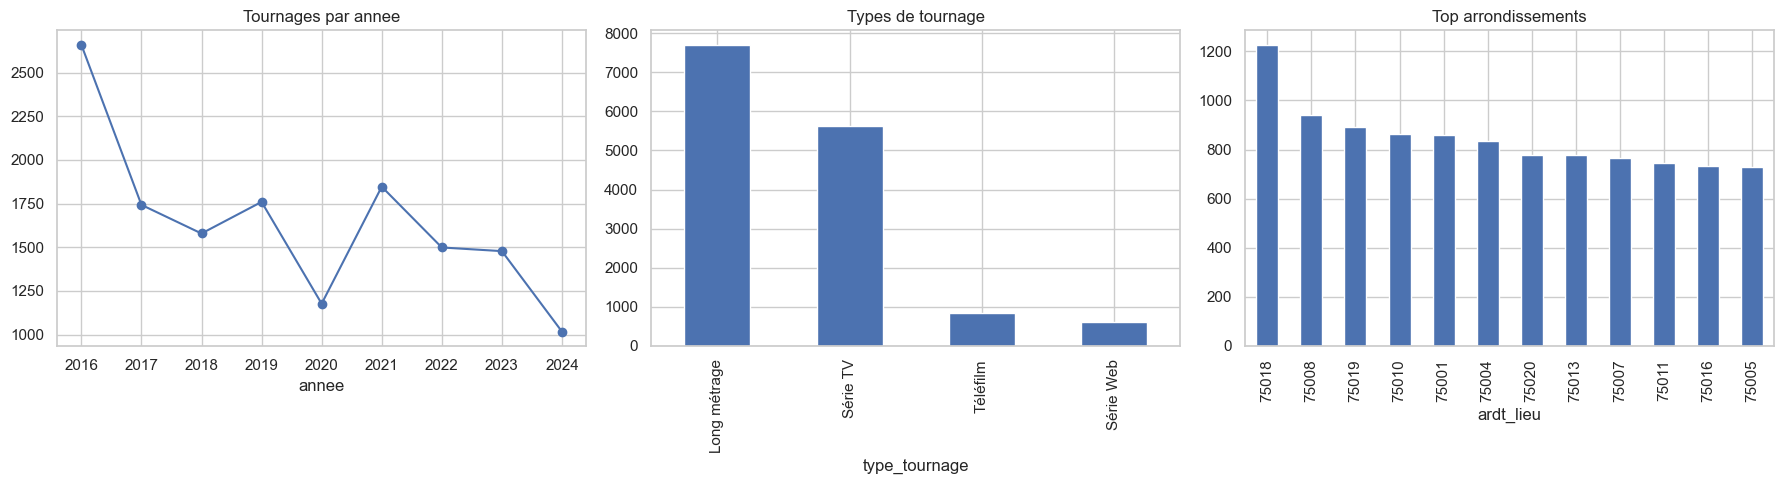

In [8]:
tournages['annee'] = tournages['annee_tournage'].astype(str).str[:4].astype(int)

display(tournages[['annee', 'type_tournage', 'nom_tournage', 'adresse_lieu', 'ardt_lieu']].head())
display(tournages['type_tournage'].value_counts().rename('tournages_by_type'))
display(tournages['ardt_lieu'].value_counts().head(15).rename('tournages_by_arrondissement'))
display(tournages['nom_tournage'].value_counts().head(15).rename('top_productions'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tournages['annee'].value_counts().sort_index().plot(kind='line', marker='o', ax=axes[0], title='Tournages par annee')
tournages['type_tournage'].value_counts().plot(kind='bar', ax=axes[1], title='Types de tournage')
tournages['ardt_lieu'].value_counts().head(12).plot(kind='bar', ax=axes[2], title='Top arrondissements')
plt.tight_layout()


## 7. Equipements sport/culture BPE 2024

GEO_OBJECT
COM        352946
BV2022     179312
EPCI       168485
UU2020     128029
ARR        122801
ZE2020     118845
AAV2020    113880
DEP         85346
REG         45404
FRANCE      33512
ARM          3201
Name: rows_by_geo_object, dtype: int64

BPE_MEASURE
FACILITIES     1088712
PLAYGROUNDS     260562
ROOMS             2487
Name: rows_by_measure, dtype: int64

,FACILITY_TYPE,OBS_VALUE,label
9,F111,734091,Plateaux et terrains de jeux extérieurs
10,F113,708764,Terrains de grands jeux
2,F103,572938,Tennis
1,F102,517406,Boulodrome
28,F203,486262,Boucle de randonnée et parcours de course d’orientation
16,F121,372151,"Salles multisports, gymnases"
12,F116,319143,Salles non spécialisées
15,F120,225594,Salles de remise en forme
4,F106,222616,Centre équestre
24,F129,215133,Salles spécialisées


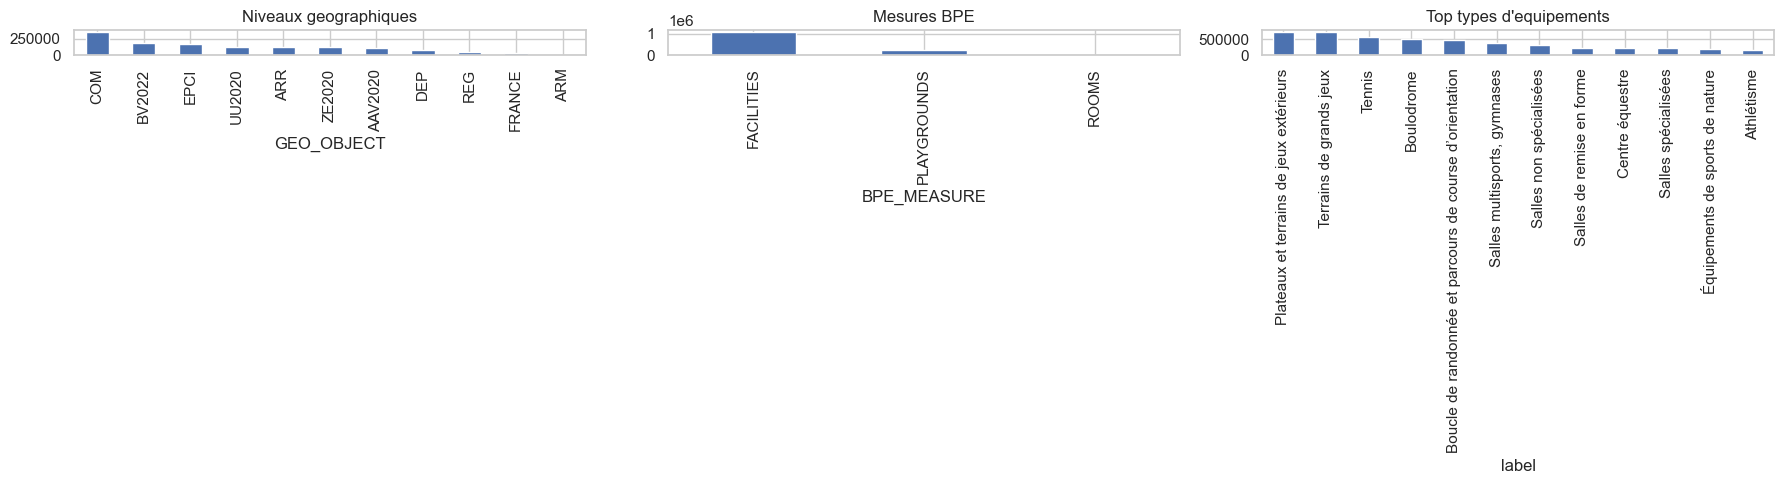

In [9]:
facility_labels = (
    bpe_meta[bpe_meta['COD_VAR'].eq('FACILITY_TYPE')]
    .drop_duplicates('COD_MOD')
    .set_index('COD_MOD')['LIB_MOD']
)

bpe_type = (
    bpe.groupby('FACILITY_TYPE', as_index=False)['OBS_VALUE'].sum()
    .sort_values('OBS_VALUE', ascending=False)
)
bpe_type['label'] = bpe_type['FACILITY_TYPE'].map(facility_labels).fillna(bpe_type['FACILITY_TYPE'])

display(bpe['GEO_OBJECT'].value_counts().rename('rows_by_geo_object'))
display(bpe['BPE_MEASURE'].value_counts().rename('rows_by_measure'))
display(bpe_type.head(20))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bpe['GEO_OBJECT'].value_counts().plot(kind='bar', ax=axes[0], title='Niveaux geographiques')
bpe['BPE_MEASURE'].value_counts().plot(kind='bar', ax=axes[1], title='Mesures BPE')
bpe_type.head(12).set_index('label')['OBS_VALUE'].plot(kind='bar', ax=axes[2], title='Top types d\'equipements')
plt.tight_layout()


## 8. Commerces par commune ou arrondissement

,departement,departement_2,libelle_de_,arrondissem,canton_vill,zone_d_empl,unite_urbai,population_,hypermarche,supermarche,grande_surf,superette,epicerie,boulangerie,boucherie_c,produits_su,poissonneri,librairie_p,magasin_de_,magasin_d_e,magasin_de__2,magasin_d_e_2,magasin_de__3,magasin_d_a,magasin_de__4,droguerie_q,parfumerie,horlogerie_,fleuriste,magasin_d_o,station_ser
0,94,94074,Valenton,941,9447,1118,00851,12081,0,3,0,0,5,5,3,2,0,2,5,0,1,0,6,0,0,0,2,0,1,0,2
1,95,95427,Montmagny,952,9509,56,00851,14250,0,1,0,0,2,2,1,0,0,1,3,0,0,0,1,1,0,0,0,1,2,1,1
2,91,91619,Torfou,911,9109,1115,91000,272,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,95,95183,Courdimanche,953,9539,1119,00851,6495,0,0,0,0,1,2,1,0,0,0,1,2,0,0,0,0,0,1,1,0,0,0,0
4,77,77197,Frétoy,773,7723,1103,77000,155,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


magasin_de_      14613
boulangerie       6299
epicerie          5491
librairie_p       4248
boucherie_c       3233
fleuriste         2839
magasin_d_o       2738
magasin_de__2     2424
magasin_d_e       2410
magasin_de__3     2244
parfumerie        1972
horlogerie_       1972
supermarche       1622
magasin_d_e_2     1589
magasin_d_a       1230
droguerie_q        985
superette          931
station_ser        899
grande_surf        392
magasin_de__4      386
Name: total_commerces, dtype: int64

,libelle_de_,population_
200,Paris 15e Arrondissement,236715
495,Paris 18e Arrondissement,202685
681,Paris 20e Arrondissement,196880
158,Paris 19e Arrondissement,186652
630,Paris 13e Arrondissement,181532
1253,Paris 16e Arrondissement,171124
1087,Paris 17e Arrondissement,169325
861,Paris 11e Arrondissement,153202
710,Paris 12e Arrondissement,144262
190,Paris 14e Arrondissement,138299


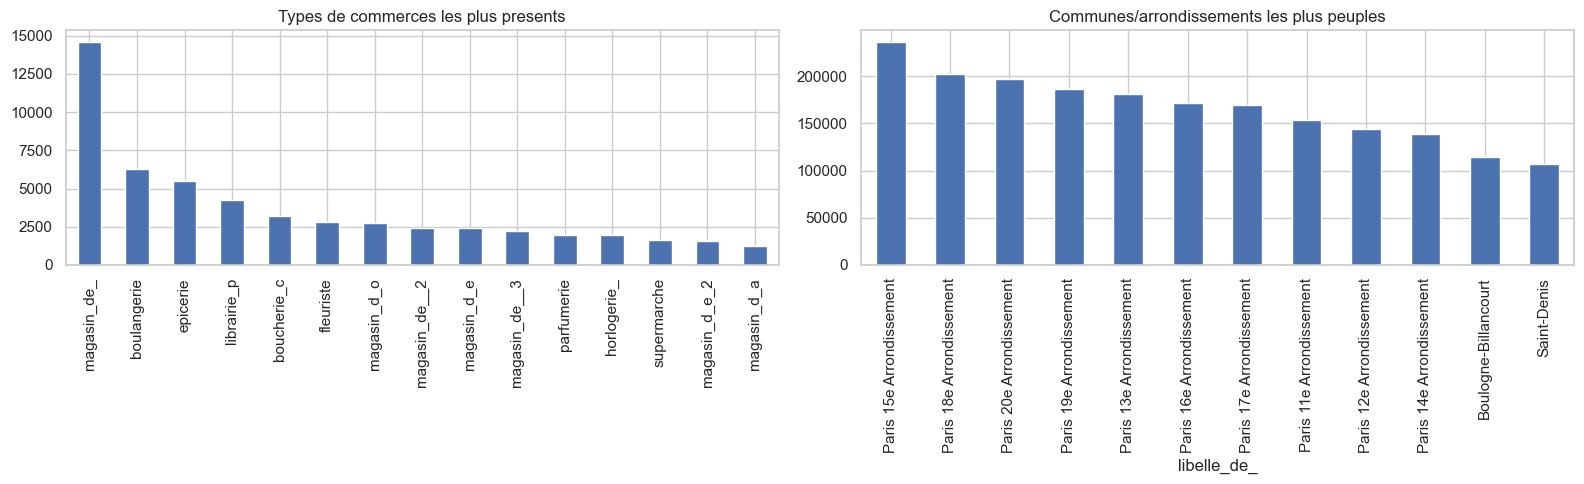

In [10]:
id_cols = ['departement', 'departement_2', 'libelle_de_', 'arrondissem', 'canton_vill', 'zone_d_empl', 'unite_urbai', 'population_']
commerce_cols = [c for c in commerces.columns if c not in id_cols]
commerce_totals = commerces[commerce_cols].sum(numeric_only=True).sort_values(ascending=False)

display(commerces.head())
display(commerce_totals.head(20).rename('total_commerces'))
display(commerces[['libelle_de_', 'population_']].sort_values('population_', ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
commerce_totals.head(15).plot(kind='bar', ax=axes[0], title='Types de commerces les plus presents')
commerces.nlargest(12, 'population_').set_index('libelle_de_')['population_'].plot(kind='bar', ax=axes[1], title='Communes/arrondissements les plus peuples')
plt.tight_layout()


## 9. Terrasses autorisees

,typologie,adresse,arrondissem,nom_enseign,nom_societe,siret,longueur,largeur,periode_ins,lien_affich,surface_m2
0,CONTRE TERRASSE ESTIVALE SUR TROTTOIR FACE À LA DEVANTURE,125 AVENUE DE CHOISY,75013,LE MANDARIN DE CHOISY,,32187797900013,3.7,2.6,,https://eudonet-terrasses.apps.paris.fr/xrm/at?tok=D6B73972&cs=yUZEpjDcLmM4cArTiYVmgR19xlDjkOjKSPVUmbMWSgMNllRK_YRuE...,9.62
1,TERRASSE ESTIVALE SUR TROTTOIR FACE À LA DEVANTURE,49 RUE DE DOUAI,75009,PERLOUSE,,83420711000018,7.5,0.5,,,3.75
2,CONTRE TERRASSE ESTIVALE SUR TROTTOIR FACE À LA DEVANTURE,234 RUE DE BERCY,75012,HOTEL SLEEPING BELLE,,39852698800082,7.2,0.6,,,4.32
3,TERRASSE ESTIVALE SUR TROTTOIR FACE À LA DEVANTURE,40 RUE CHAPON,75003,COFFEE SPECIALTY COFFEE,,90887207000028,2.7,0.6,,,1.62
4,CONTRE TERRASSE ESTIVALE SUR STATIONNEMENT,49 RUE DE LA FOLIE MERICOURT,75011,LA CANTINE GOURMANDE,,82050511300010,3.7,1.7,,https://eudonet-terrasses.apps.paris.fr/xrm/at?tok=D6B73972&cs=yUZEpjDcLmM4cArTiYVmgUJx2uOYSAiWgqIEiwtS5k0ByGWsK1Cat...,6.29


arrondissem
75015    1687
75010    1594
75017    1538
75011    1533
75018    1492
75009    1365
75012    1363
75014    1294
75005    1287
75008    1165
75020    1150
75013    1068
75019     896
75004     876
75001     835
Name: terrasses_by_arrondissement, dtype: int64

typologie
TERRASSE OUVERTE                                                     8494
ETALAGE                                                              4246
TERRASSES OUVERTES SUR TROTTOIR                                      2343
CONTRE TERRASSE ESTIVALE SUR STATIONNEMENT                           2279
TERRASSE FERMÉE                                                      1781
TERRASSE ESTIVALE SUR TROTTOIR FACE À LA DEVANTURE                   1213
CONTRE TERRASSE ESTIVALE SUR TROTTOIR FACE À LA DEVANTURE             851
ÉTALAGE SUR TROTTOIR                                                  462
COMMERCE ACCESSOIRE                                                   304
CONTRE-TERRASSE PERMANENTE SUR STATIONNEMENT                          284
PLANCHER MOBILE                                                       249
CONTRE-TERRASSE OUVERTE                                               209
TERRASSES OUVERTES SUR VOIE PIÉTONNE                                  192
TERRASSE ESTIVALE SUR TROTTO

count    23864.00
mean         9.18
std         12.60
min          0.00
25%          3.42
50%          6.37
75%         11.41
max        900.00
Name: surface_m2, dtype: float64

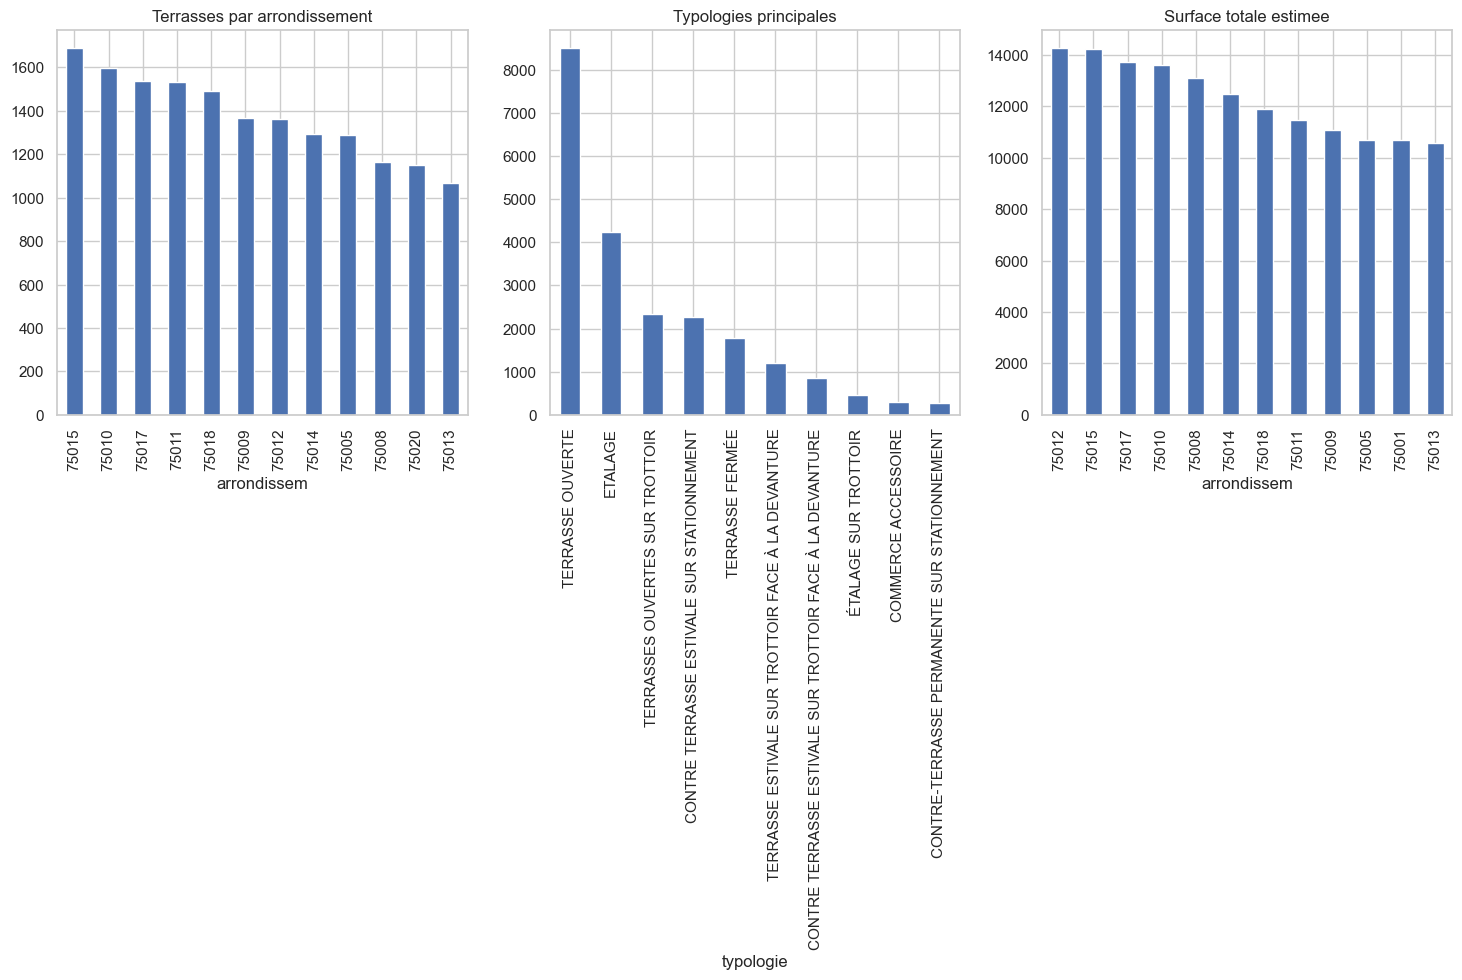

In [11]:
terrasses['surface_m2'] = pd.to_numeric(terrasses['longueur'], errors='coerce') * pd.to_numeric(terrasses['largeur'], errors='coerce')

display(terrasses.head())
display(terrasses['arrondissem'].value_counts().head(15).rename('terrasses_by_arrondissement'))
display(terrasses['typologie'].value_counts().head(15).rename('terrasses_by_typologie'))
display(terrasses['surface_m2'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
terrasses['arrondissem'].value_counts().head(12).plot(kind='bar', ax=axes[0], title='Terrasses par arrondissement')
terrasses['typologie'].value_counts().head(10).plot(kind='bar', ax=axes[1], title='Typologies principales')
terrasses.groupby('arrondissem')['surface_m2'].sum().sort_values(ascending=False).head(12).plot(kind='bar', ax=axes[2], title='Surface totale estimee')
plt.tight_layout()


## 10. Zones touristiques internationales

In [12]:
display(zones[['name', 'type', 'boundary', 'source', '_timestamp']])
zones['name'].tolist()


,name,type,boundary,source,_timestamp
0,Saint-Honoré - Vendôme,boundary,tourist_zone,JORFTEXT000031223603,2016-07-26T17:22:16Z
1,Montmartre,boundary,tourist_zone,JORFTEXT000031223591,2016-07-26T16:15:57Z
2,Olympiades,boundary,tourist_zone,JORFTEXT000031223594,2016-07-26T16:39:02Z
3,Le Marais,multipolygon,tourist_zone,JORFTEXT000031223582,2016-07-26T15:30:19Z
4,Rennes - Saint-Sulpice,boundary,tourist_zone,JORFTEXT000031223597,2016-07-26T17:30:29Z
5,Maillot-Ternes,boundary,tourist_zone,JORFTEXT000031223588,2016-07-26T15:53:40Z
6,Saint-Germain,boundary,tourist_zone,JORFTEXT000031223606,2016-07-26T17:30:29Z
7,Haussmann,multipolygon,tourist_zone,JORFTEXT000031223579,2016-07-26T17:22:16Z
8,Les Halles,boundary,tourist_zone,JORFTEXT000031223585,2016-07-26T17:22:16Z
9,Champs-Elysées Montaigne,boundary,tourist_zone,JORFTEXT000031223576,2016-07-26T14:10:50Z


['Saint-Honoré - Vendôme',
 'Montmartre',
 'Olympiades',
 'Le Marais',
 'Rennes - Saint-Sulpice',
 'Maillot-Ternes',
 'Saint-Germain',
 'Haussmann',
 'Les Halles',
 'Champs-Elysées Montaigne',
 'Saint-Emilion Bibliothèque',
 'Beaugrenelle']

## Synthese initiale

- Le dossier contient 8 tables exploitables: 4 Parquet, 2 CSV BPE, et 2 shapefiles dont les attributs sont lus via DBF.
- Les donnees couvrent surtout Paris / Ile-de-France: evenements, associations, tournages, terrasses, commerces, zones touristiques, equipements sport/culture.
- Points d'attention: encodage imparfait dans certains DBF/Parquet, noms DBF tronques/dupliques, nombreuses colonnes tres vides dans `que-faire-a-paris`, et doublons apparents dans les associations.
- Piste projet possible: construire un indicateur d'attractivite locale par arrondissement en croisant evenements, terrasses, commerces, associations, tournages et zones touristiques.